In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [2]:
df_train = pd.read_csv('trainset.csv')
df_test = pd.read_csv('testset.csv')

In [3]:
train_prices = df_train['Close'].values.reshape(-1, 1)
test_prices = df_test['Close'].values.reshape(-1, 1)

In [4]:
scaler = MinMaxScaler()
scaled_train = scaler.fit_transform(train_prices)
scaled_test = scaler.transform(test_prices)

In [5]:
def create_sequences (data, seq_length):
  x = []
  y = []
  for i in range(len(data) - seq_length):
    x.append(data[i:i+seq_length])
    y.append(data[i+seq_length])
  return np.array(x), np.array(y)

In [7]:
seq_length = 60
x_train, y_train = create_sequences (scaled_train, seq_length)
x_test, y_test = create_sequences (scaled_test, seq_length)
x_train.shape, y_train.shape, x_test.shape, y_test.shape


((1199, 60, 1), (1199, 1), (65, 60, 1), (65, 1))

In [8]:
x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)
y_test_tensor = torch.tensor (y_test, dtype=torch.float32)


In [9]:
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [10]:
class RNNModel (nn.Module):
  def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1):
    super (RNNModel, self).__init__()
    self.rnn = nn. RNN(input_size, hidden_size, num_layers, batch_first=True)
    self.fc = nn. Linear(hidden_size, output_size)
  def forward(self, x):
    out,_=self.rnn(x)
    out=self.fc (out[:,-1,:])
    return out

In [11]:
model = RNNModel()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to (device)

In [12]:
!pip install torchinfo


In [13]:
from torchinfo import summary
summary(model, input_size=(64,60,1))

Layer (type:depth-idx)                   Output Shape              Param #
RNNModel                                 [64, 1]                   --
├─RNN: 1-1                               [64, 60, 64]              12,608
├─Linear: 1-2                            [64, 1]                   65
Total params: 12,673
Trainable params: 12,673
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 48.42
Input size (MB): 0.02
Forward/backward pass size (MB): 1.97
Params size (MB): 0.05
Estimated Total Size (MB): 2.03

In [14]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [15]:
def train_model(model, train_loader, criterion, optimizer, epochs=20):
  train_losses = []
  model.train()
  for epoch in range(epochs):
    total_loss = 0
    for x_batch, y_batch in train_loader:
      x_batch, y_batch = x_batch.to(device), y_batch.to(device)
      optimizer.zero_grad()
      outputs = model(x_batch)
      loss = criterion(outputs, y_batch)
      loss.backward()
      optimizer.step()
      total_loss += loss.item()
    train_losses.append(total_loss/len(train_loader))
    print(f"Epoch: [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.4f}")
    
  plt.plot(train_losses, label='Trainng Loss')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.title('Training Loss Over Epochs')
  plt.legend()
  plt.show()

Epoch: [1/20], Loss: 0.0378
Epoch: [2/20], Loss: 0.0027
Epoch: [3/20], Loss: 0.0006
Epoch: [4/20], Loss: 0.0004
Epoch: [5/20], Loss: 0.0004
Epoch: [6/20], Loss: 0.0003
Epoch: [7/20], Loss: 0.0004
Epoch: [8/20], Loss: 0.0003
Epoch: [9/20], Loss: 0.0003
Epoch: [10/20], Loss: 0.0003
Epoch: [11/20], Loss: 0.0003
Epoch: [12/20], Loss: 0.0003
Epoch: [13/20], Loss: 0.0003
Epoch: [14/20], Loss: 0.0003
Epoch: [15/20], Loss: 0.0003
Epoch: [16/20], Loss: 0.0003
Epoch: [17/20], Loss: 0.0003
Epoch: [18/20], Loss: 0.0003
Epoch: [19/20], Loss: 0.0003
Epoch: [20/20], Loss: 0.0003


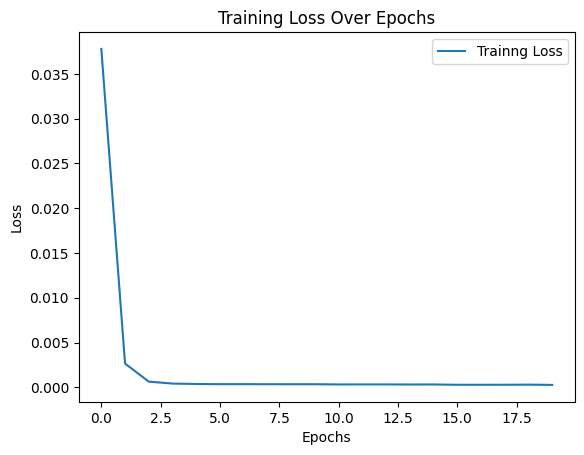

In [16]:
train_model(model, train_loader, criterion, optimizer)

In [17]:
model.eval()
with torch.no_grad():
  predicted = model(x_test_tensor.to(device)).cpu().numpy()

In [18]:
predicted_prices = scaler.inverse_transform(predicted)
actual_prices = scaler.inverse_transform(y_test)

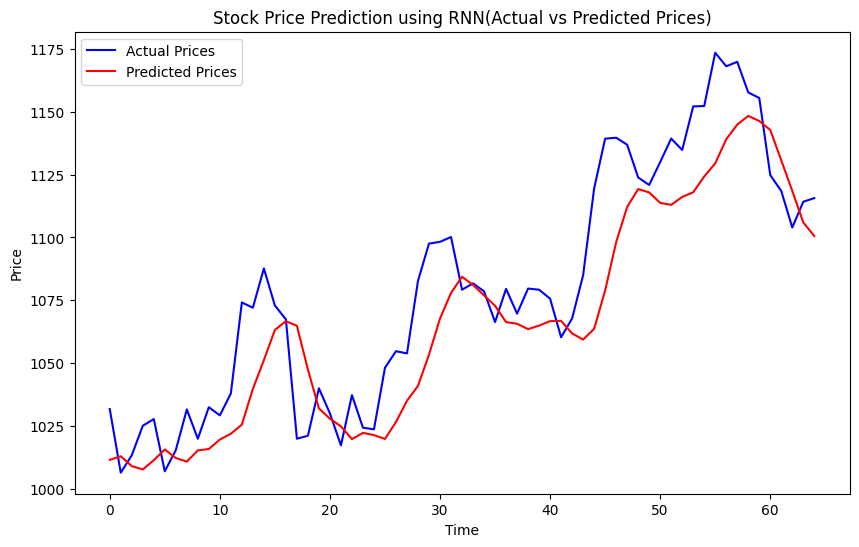

Predicted Price: [1100.5757]
Actual Price: [1115.650024] 


In [19]:
plt.figure(figsize=(10, 6))
plt.plot(actual_prices, label='Actual Prices', color='blue')
plt.plot(predicted_prices, label='Predicted Prices', color='red')
plt.xlabel('Time')
plt.ylabel('Price')
plt.title('Stock Price Prediction using RNN(Actual vs Predicted Prices)')
plt.legend()
plt.show()

print(f"Predicted Price: {predicted_prices[-1]}")
print(f"Actual Price: {actual_prices[-1]} ")